# Compulsory Assignment #1
## Machine Learning and Deep Learning (CDSCO2041C)

**Group Members Student IDs:** [INSERT STUDENT IDs HERE]

---

## Setup & Data Loading

In [52]:
#librerie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [53]:
# ---------------------------------------------------------------
# LOAD THE DATASET
# UK Greenhouse Gas Emissions by Source 
# Sheet: UK_by_source
# ---------------------------------------------------------------
df = pd.read_excel('dataset/greenhouse-gas-emissions-1.xlsx', sheet_name='UK_by_source')

print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
df.head()

KeyboardInterrupt: 

In [ ]:
# Basic inspection
print('Data Types:')
print(df.dtypes)
print('\nNull values per column:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Data Types:
Included in UK territorial total               object
GHG                                            object
GHG grouped                                    object
CRT category                                   object
CRT category description                       object
Year                                            int64
Territory name                                 object
Territorial Emissions Statistics sector        object
Territorial Emissions Statistics subsector     object
Territorial Emissions Statistics category      object
Source                                         object
Fuel group                                     object
Fuel                                           object
Activity                                       object
Emissions (MtCO2e)                            float64
dtype: object

Null values per column:
Included in UK territorial total              0
GHG                                           0
GHG grouped                                

,Year,Emissions (MtCO2e)
count,78022.000000,78022.000000
mean,2007.771295,0.293069
std,9.982078,3.036902
min,1990.000000,-18.002028
25%,1999.000000,0.000124
50%,2008.000000,0.002087
75%,2016.000000,0.026358
max,2024.000000,184.014756


In [ ]:
print(df.columns.tolist())

['Included in UK territorial total', 'GHG', 'GHG grouped', 'CRT category', 'CRT category description', 'Year', 'Territory name', 'Territorial Emissions Statistics sector', 'Territorial Emissions Statistics subsector', 'Territorial Emissions Statistics category', 'Source', 'Fuel group', 'Fuel', 'Activity', 'Emissions (MtCO2e)']


In [ ]:
YEAR_COL     = 'Year'
EMISSION_COL = 'Emissions (MtCO2e)'
SOURCE_COL   = 'Source'
ACTIVITY_COL = 'Activity'
FUEL_COL     = 'Fuel group'
TERR_COL     = 'Included in UK territorial total'
# ---------------------------------------------------------------
# DATA CLEANING
# ---------------------------------------------------------------

df_clean = df.copy()

print(f'Clean dataset shape : {df_clean.shape}')
print(f'Year range          : {df_clean[YEAR_COL].min()} - {df_clean[YEAR_COL].max()}')
df_clean.head()

Clean dataset shape : (78022, 15)
Year range          : 1990 - 2024


,Included in UK territorial total,GHG,GHG grouped,CRT category,CRT category description,Year,Territory name,Territorial Emissions Statistics sector,Territorial Emissions Statistics subsector,Territorial Emissions Statistics category,Source,Fuel group,Fuel,Activity,Emissions (MtCO2e)
0,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft - international take off and landing,Petroleum,Aviation turbine fuel,Aviation turbine fuel,0.008548
1,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft - international take off and landing,Petroleum,Other petroleum products,Aviation spirit,0.000008
2,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft between UK and Bermuda - TOL,Petroleum,Aviation turbine fuel,Aviation turbine fuel,0.000012
3,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft between UK and CDs - TOL,Petroleum,Aviation turbine fuel,Aviation turbine fuel,0.000735
4,No,CH4,CH4,1D1a,International Aviation,1990,United Kingdom,International aviation and shipping,International aviation and shipping,International aviation,Aircraft between UK and CDs - TOL,Petroleum,Other petroleum products,Aviation spirit,0.000007


---
# Question 1 – Exploratory Data Analysis (EDA)

## Q1.1 – Custom Covariance & Correlation Analysis

We implement **covariance** and **Pearson correlation** from scratch without using any built-in statistical functions (`df.corr()`, `np.corrcoef()`, etc.).

$$\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

$$r_{XY} = \frac{\text{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y}$$

In [ ]:
# ---------------------------------------------------------------
# CUSTOM STATISTICAL FUNCTIONS  (no built-in cov/corr allowed)
# ---------------------------------------------------------------

def custom_mean(x):
    """Arithmetic mean without using np.mean."""
    return sum(x) / len(x)


def custom_covariance(x, y):
    """
    Population covariance between two 1-D arrays x and y.
    Cov(X,Y) = (1/n) * sum( (xi - x_mean) * (yi - y_mean) )
    """
    if len(x) != len(y):
        raise ValueError('Arrays must have the same length.')
    n = len(x)
    x_mean = custom_mean(x)
    y_mean = custom_mean(y)
    cov = sum((x[i] - x_mean) * (y[i] - y_mean) for i in range(n)) / n
    return cov


def custom_std(x):
    """Population standard deviation."""
    x_mean = custom_mean(x)
    variance = sum((xi - x_mean) ** 2 for xi in x) / len(x)
    return variance ** 0.5


def custom_pearson(x, y):
    """
    Pearson correlation coefficient.
    r = Cov(X,Y) / (std(X) * std(Y))
    """
    cov = custom_covariance(x, y)
    sx  = custom_std(x)
    sy  = custom_std(y)
    if sx == 0 or sy == 0:
        return 0.0   # undefined correlation for constant variables
    return cov / (sx * sy)


def custom_corr_matrix(df_pivot):
    """
    Build a full correlation matrix for a DataFrame where rows = observations,
    columns = variables.  Returns a DataFrame.
    """
    cols = df_pivot.columns.tolist()
    n = len(cols)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x = df_pivot.iloc[:, i].tolist()
            y = df_pivot.iloc[:, j].tolist()
            matrix[i, j] = custom_pearson(x, y)
    return pd.DataFrame(matrix, index=cols, columns=cols)


def custom_cov_matrix(df_pivot):
    """Build a full covariance matrix for a DataFrame."""
    cols = df_pivot.columns.tolist()
    n = len(cols)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x = df_pivot.iloc[:, i].tolist()
            y = df_pivot.iloc[:, j].tolist()
            matrix[i, j] = custom_covariance(x, y)
    return pd.DataFrame(matrix, index=cols, columns=cols)


print('Custom functions defined.')

Custom functions defined.


In [ ]:
# PIVOT: total emissions per SOURCE per YEAR
# ---------------------------------------------------------------
pivot_source = (df_clean.groupby([YEAR_COL, SOURCE_COL])[EMISSION_COL]
    .sum()
    .unstack(SOURCE_COL)
    .fillna(0)
)

print('Pivot shape (years x sources):', pivot_source.shape)
pivot_source.head()

Pivot shape (years x sources): (35, 700)


Source,Abandoned oil wells (offshore),Abandoned oil wells (onshore),Accidental fires - dwellings,Accidental fires - other buildings,Accidental fires - vehicles,Adipic acid production,Aerosols other than metered dose inhalers,Agricultural Horses - Direct,Agricultural Horses - Indirect Deposition,Agricultural Horses - Indirect Leach,...,Upstream Oil Production - Offshore Well Testing,Upstream Oil Production - Oil terminal storage,Upstream Oil Production - Onshore Oil Loading,Upstream Oil Production - flaring,Upstream Oil Production - fuel combustion,Upstream Oil Production - fugitive emissions,Upstream Oil Production - venting,Upstream Oil Production: direct process emissions,Well exploration (unconventional gas): all sources,Wildfires
Year,,,,,,,,,,,,,,,,,,,,,
1990,0.000032,0.000523,0.007963,0.018494,0.001793,17.727085,0.000000,0.038347,0.004704,0.003355,...,0.425799,0.000123,0.043785,4.145231,9.598660,0.069816,0.247765,0.351668,0.0,0.061387
1991,0.000034,0.000527,0.007936,0.015709,0.002070,17.823582,0.000000,0.039752,0.004876,0.003478,...,0.404999,0.000118,0.041333,3.995975,9.350138,0.067302,0.238844,0.305875,0.0,0.093121
1992,0.000036,0.000530,0.007881,0.015559,0.002073,13.750002,0.000000,0.040954,0.005024,0.003583,...,0.369515,0.000121,0.041423,4.096585,10.278768,0.068997,0.244857,0.346061,0.0,0.036715
1993,0.000038,0.000531,0.007581,0.014458,0.002087,10.350900,0.080013,0.047273,0.005799,0.004136,...,0.342597,0.000129,0.037822,4.336500,10.881922,0.073038,0.259197,0.244219,0.0,0.051943
1994,0.000040,0.000535,0.007509,0.014122,0.001931,11.482086,0.240038,0.049339,0.006052,0.004317,...,0.376857,0.000163,0.037904,5.498342,11.287306,0.092606,0.328642,0.112690,0.0,0.045277


In [ ]:
# ---------------------------------------------------------------
# CORRELATION MATRIX between emission sources (custom)
# ---------------------------------------------------------------
corr_sources = custom_corr_matrix(pivot_source)

print('Correlation matrix (sources):')
corr_sources.round(3)

Correlation matrix (sources):


,Abandoned oil wells (offshore),Abandoned oil wells (onshore),Accidental fires - dwellings,Accidental fires - other buildings,Accidental fires - vehicles,Adipic acid production,Aerosols other than metered dose inhalers,Agricultural Horses - Direct,Agricultural Horses - Indirect Deposition,Agricultural Horses - Indirect Leach,...,Upstream Oil Production - Offshore Well Testing,Upstream Oil Production - Oil terminal storage,Upstream Oil Production - Onshore Oil Loading,Upstream Oil Production - flaring,Upstream Oil Production - fuel combustion,Upstream Oil Production - fugitive emissions,Upstream Oil Production - venting,Upstream Oil Production: direct process emissions,Well exploration (unconventional gas): all sources,Wildfires
Abandoned oil wells (offshore),1.000,0.986,-0.946,-0.948,-0.889,-0.829,-0.007,0.032,0.032,0.032,...,-0.823,-0.026,-0.971,-0.815,-0.790,-0.587,-0.001,-0.680,0.236,0.270
Abandoned oil wells (onshore),0.986,1.000,-0.921,-0.936,-0.861,-0.877,0.128,0.152,0.152,0.152,...,-0.868,0.042,-0.974,-0.806,-0.752,-0.583,0.002,-0.703,0.287,0.242
Accidental fires - dwellings,-0.946,-0.921,1.000,0.964,0.975,0.658,0.214,0.094,0.094,0.094,...,0.716,0.155,0.951,0.858,0.920,0.534,0.050,0.466,-0.280,-0.229
Accidental fires - other buildings,-0.948,-0.936,0.964,1.000,0.933,0.717,0.119,0.055,0.055,0.055,...,0.716,0.140,0.941,0.789,0.835,0.492,-0.027,0.550,-0.335,-0.226
Accidental fires - vehicles,-0.889,-0.861,0.975,0.933,1.000,0.547,0.275,0.094,0.094,0.094,...,0.605,0.245,0.890,0.797,0.932,0.441,0.035,0.368,-0.325,-0.272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Upstream Oil Production - fugitive emissions,-0.587,-0.583,0.534,0.492,0.441,0.578,-0.048,0.014,0.014,0.014,...,0.656,-0.131,0.629,0.631,0.445,1.000,0.197,0.315,0.280,0.052
Upstream Oil Production - venting,-0.001,0.002,0.050,-0.027,0.035,-0.013,0.167,0.042,0.042,0.042,...,0.115,-0.209,0.075,0.321,0.207,0.197,1.000,-0.136,0.168,0.183
Upstream Oil Production: direct process emissions,-0.680,-0.703,0.466,0.550,0.368,0.800,-0.434,-0.312,-0.312,-0.312,...,0.649,-0.182,0.612,0.323,0.210,0.315,-0.136,1.000,-0.191,-0.233
Well exploration (unconventional gas): all sources,0.236,0.287,-0.280,-0.335,-0.325,-0.210,0.070,0.132,0.132,0.132,...,-0.211,-0.212,-0.253,-0.198,-0.273,0.280,0.168,-0.191,1.000,0.340


In [ ]:
# ---------------------------------------------------------------
# COVARIANCE MATRIX between emission sources (custom)
# ---------------------------------------------------------------
cov_sources = custom_cov_matrix(pivot_source)

print('Covariance matrix (sources):')
cov_sources.round(2)

Covariance matrix (sources):


,Abandoned oil wells (offshore),Abandoned oil wells (onshore),Accidental fires - dwellings,Accidental fires - other buildings,Accidental fires - vehicles,Adipic acid production,Aerosols other than metered dose inhalers,Agricultural Horses - Direct,Agricultural Horses - Indirect Deposition,Agricultural Horses - Indirect Leach,...,Upstream Oil Production - Offshore Well Testing,Upstream Oil Production - Oil terminal storage,Upstream Oil Production - Onshore Oil Loading,Upstream Oil Production - flaring,Upstream Oil Production - fuel combustion,Upstream Oil Production - fugitive emissions,Upstream Oil Production - venting,Upstream Oil Production: direct process emissions,Well exploration (unconventional gas): all sources,Wildfires
Abandoned oil wells (offshore),0.0,0.0,-0.0,-0.0,-0.0,-0.00,-0.00,0.0,0.0,0.0,...,-0.00,-0.0,-0.0,-0.00,-0.00,-0.0,-0.00,-0.00,0.0,0.00
Abandoned oil wells (onshore),0.0,0.0,-0.0,-0.0,-0.0,-0.00,0.00,0.0,0.0,0.0,...,-0.00,0.0,-0.0,-0.00,-0.00,-0.0,0.00,-0.00,0.0,0.00
Accidental fires - dwellings,-0.0,-0.0,0.0,0.0,0.0,0.01,0.00,0.0,0.0,0.0,...,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,-0.0,-0.00
Accidental fires - other buildings,-0.0,-0.0,0.0,0.0,0.0,0.02,0.00,0.0,0.0,0.0,...,0.00,0.0,0.0,0.00,0.01,0.0,-0.00,0.00,-0.0,-0.00
Accidental fires - vehicles,-0.0,-0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,...,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,-0.0,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Upstream Oil Production - fugitive emissions,-0.0,-0.0,0.0,0.0,0.0,0.07,-0.00,0.0,0.0,0.0,...,0.00,-0.0,0.0,0.02,0.02,0.0,0.00,0.00,0.0,0.00
Upstream Oil Production - venting,-0.0,0.0,0.0,-0.0,0.0,-0.01,0.01,0.0,0.0,0.0,...,0.00,-0.0,0.0,0.03,0.03,0.0,0.01,-0.00,0.0,0.00
Upstream Oil Production: direct process emissions,-0.0,-0.0,0.0,0.0,0.0,0.45,-0.02,-0.0,-0.0,-0.0,...,0.01,-0.0,0.0,0.04,0.04,0.0,-0.00,0.01,-0.0,-0.00
Well exploration (unconventional gas): all sources,0.0,0.0,-0.0,-0.0,-0.0,-0.00,0.00,0.0,0.0,0.0,...,-0.00,-0.0,-0.0,-0.00,-0.00,0.0,0.00,-0.00,0.0,0.00


In [ ]:
# ---------------------------------------------------------------
# CORRELATION between YEAR and each source (trend direction)
# ---------------------------------------------------------------
years = list(pivot_source.index)
trend_corr = {}
for col in pivot_source.columns:
    values = pivot_source[col].tolist()
    trend_corr[col] = round(custom_pearson(years, values), 4)

trend_series = pd.Series(trend_corr).sort_values()
print('Correlation of each source with Year (trend):')  
print(trend_series.to_string())

Correlation of each source with Year (trend):
Carbon stock change in living biomass - Gains - Below-ground biomass - Broadleaf Mineral                                         -0.9998
Carbon stock change in living biomass - Gains - Above-ground biomass - Broadleaf Mineral                                         -0.9992
Other emissive applications of Soda Ash                                                                                          -0.9947
Organic Soils - Cropland Drained - Remaining Cropland Drained - Deep peat                                                        -0.9947
Net carbon stock change in soils - Organic Soils - Cropland Drained - Remaining Cropland Drained - Deep peat                     -0.9947
Carbon stock change in living biomass - Gains - Below-ground biomass - Broadleaf Organic                                         -0.9930
Net carbon stock change in soils - Mineral Soils - Conifer Mineral                                                               -0.

### Interpretation of Covariance & Correlation Results

- **Positive correlation** between two sources means that when emissions from one source increase, the other tends to increase as well (e.g., both driven by economic growth).
- **Negative correlation** suggests opposing trends (e.g., one sector decarbonises while another grows).
- A strong **negative correlation with Year** signals a sector that has consistently reduced emissions over time.
- A strong **positive correlation with Year** signals a growing source (e.g., international aviation).

> **Note on covariance vs correlation:** Covariance is scale-dependent (affected by the size of emissions values), so sectors with very large absolute emissions dominate the covariance matrix. The correlation coefficient normalises this, making it more interpretable for comparing sources of different sizes.

## Q1.2 – Visualisation of EDA Findings

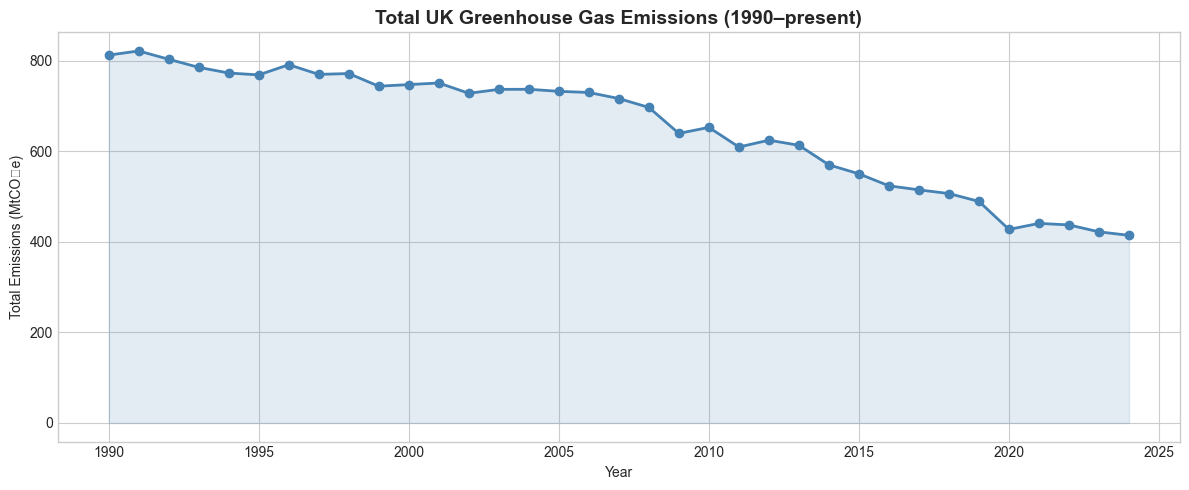

The chart shows a clear long-term decline in UK territorial emissions since 1990.


In [ ]:
# ---------------------------------------------------------------
# PLOT 1 – Total UK GHG emissions over time
# ---------------------------------------------------------------
total_by_year = df_clean.groupby(YEAR_COL)[EMISSION_COL].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(total_by_year.index, total_by_year.values, marker='o', linewidth=2, color='steelblue')
ax.fill_between(total_by_year.index, total_by_year.values, alpha=0.15, color='steelblue')
ax.set_title('Total UK Greenhouse Gas Emissions (1990–present)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Emissions (MtCO₂e)')
plt.tight_layout()
plt.savefig('plot1_total_emissions.png', dpi=150)
plt.show()
print('The chart shows a clear long-term decline in UK territorial emissions since 1990.')

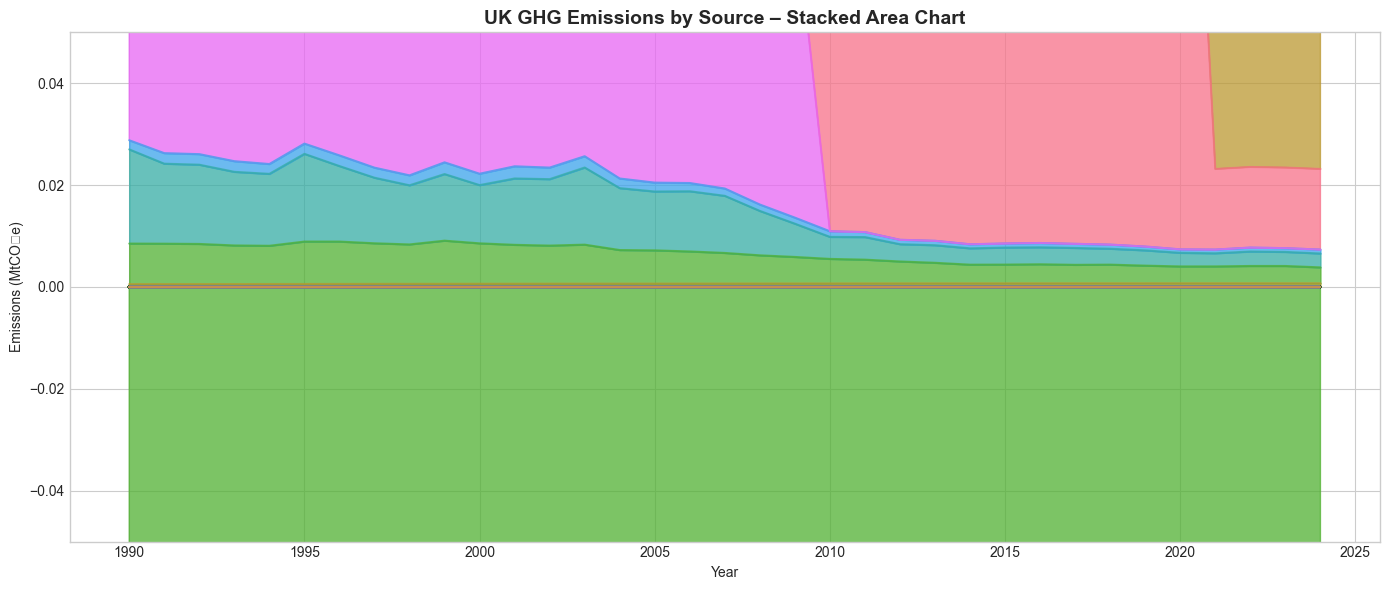

In [54]:
# ---------------------------------------------------------------
# PLOT 2 – Emissions by source over time (stacked area)
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

pivot_pos = pivot_source.clip(lower=0)
pivot_neg = pivot_source.clip(upper=0)

pivot_pos.plot(kind='area', stacked=True, ax=ax, alpha=0.75, legend=False)
pivot_neg.plot(kind='area', stacked=True, ax=ax, alpha=0.75, legend=False)

ax.set_title('UK GHG Emissions by Source – Stacked Area Chart', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (MtCO₂e)')
plt.tight_layout()
plt.savefig('plot2_stacked_sources.png', dpi=150)
plt.show()

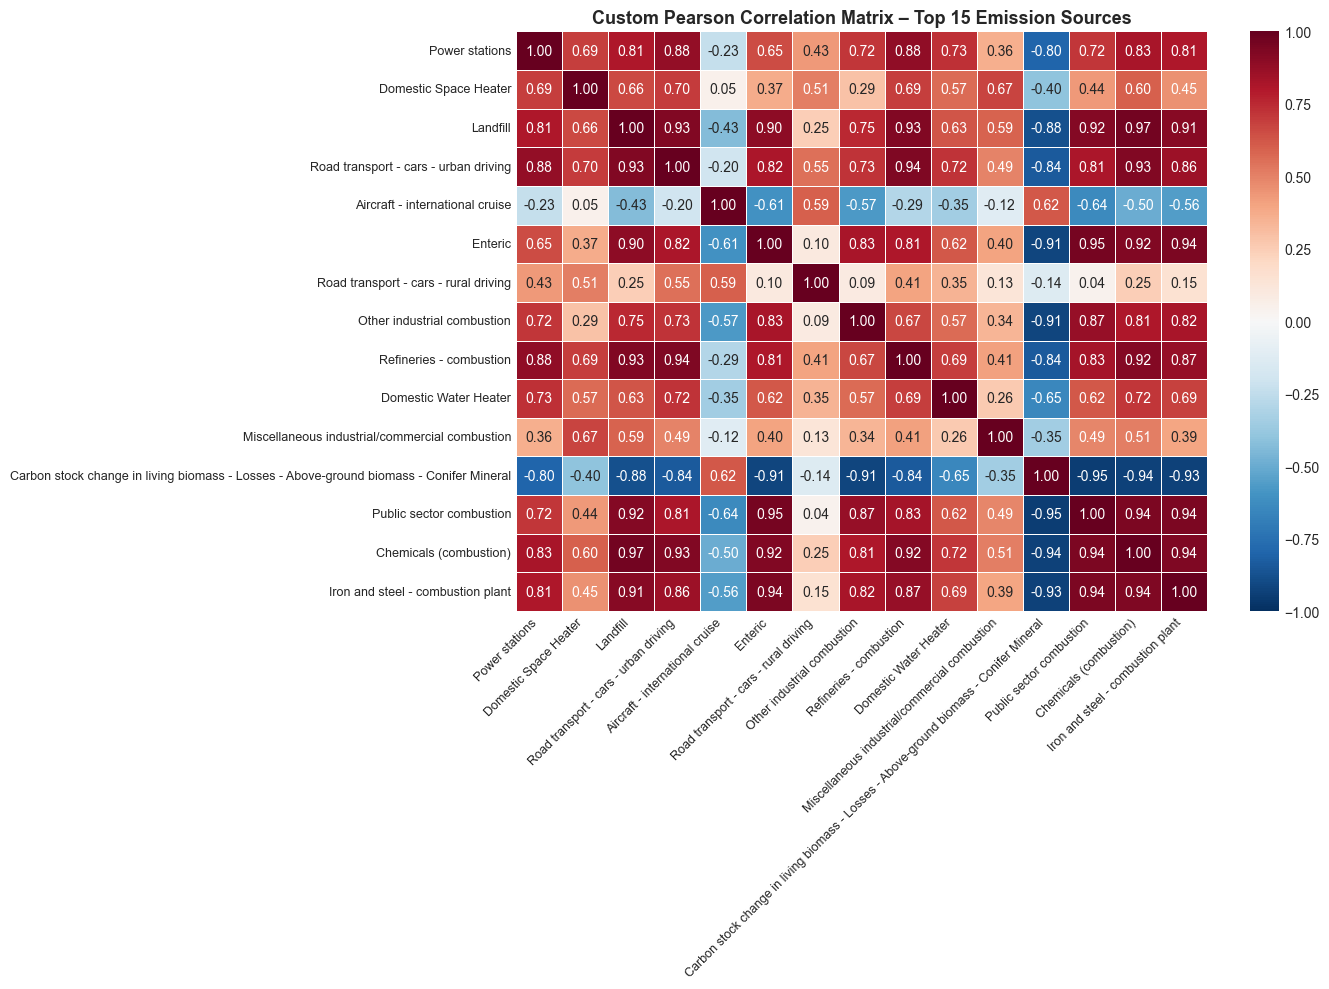

Red = strong positive correlation | Blue = strong negative correlation


In [57]:
# ---------------------------------------------------------------
# PLOT 3 – Correlation heatmap (top 15 sources)
# ---------------------------------------------------------------

# Seleziona solo le top 15 sources per emissioni totali
top15 = pivot_source.sum().nlargest(15).index
corr_top15 = custom_corr_matrix(pivot_source[top15])

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_top15,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Custom Pearson Correlation Matrix – Top 15 Emission Sources', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('plot3_corr_heatmap.png', dpi=150)
plt.show()
print('Red = strong positive correlation | Blue = strong negative correlation')

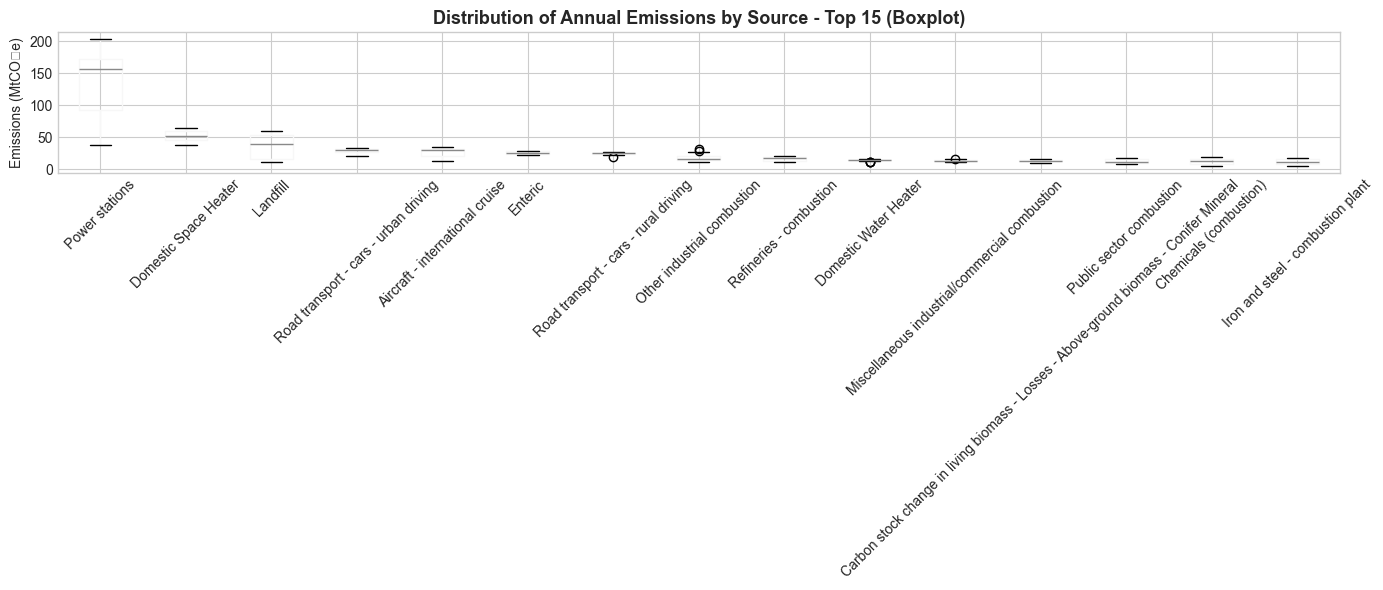

Boxplots reveal median emission levels and variability across years for each source.


In [61]:
# ---------------------------------------------------------------
# PLOT 4 – Boxplots: distribution of annual emissions per source
# ---------------------------------------------------------------
top15 = pivot_source.sum().nlargest(15).index

fig, ax = plt.subplots(figsize=(14, 6))
pivot_source[top15].boxplot(ax=ax, rot=45)
ax.set_title('Distribution of Annual Emissions by Source - Top 15 (Boxplot)', fontsize=13, fontweight='bold')
ax.set_ylabel('Emissions (MtCO₂e)')
plt.tight_layout()
plt.savefig('plot4_boxplots.png', dpi=150)
plt.show()
print('Boxplots reveal median emission levels and variability across years for each source.')

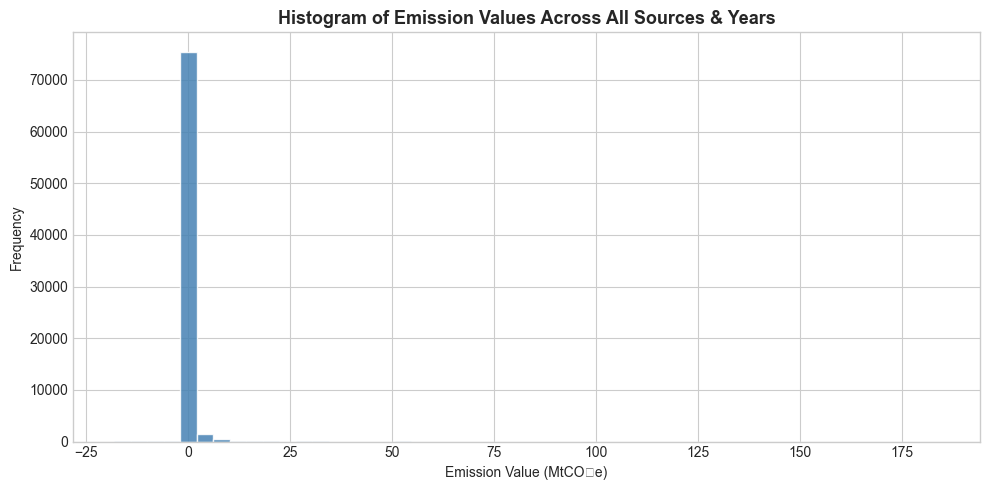

The distribution is right-skewed: most individual activity-level values are small.


In [58]:
# ---------------------------------------------------------------
# PLOT 5 – Histogram of overall emission value distribution
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean[EMISSION_COL], bins=50, edgecolor='white', color='steelblue', alpha=0.85)
ax.set_title('Histogram of Emission Values Across All Sources & Years', fontsize=13, fontweight='bold')
ax.set_xlabel('Emission Value (MtCO₂e)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot5_histogram.png', dpi=150)
plt.show()
print('The distribution is right-skewed: most individual activity-level values are small.')

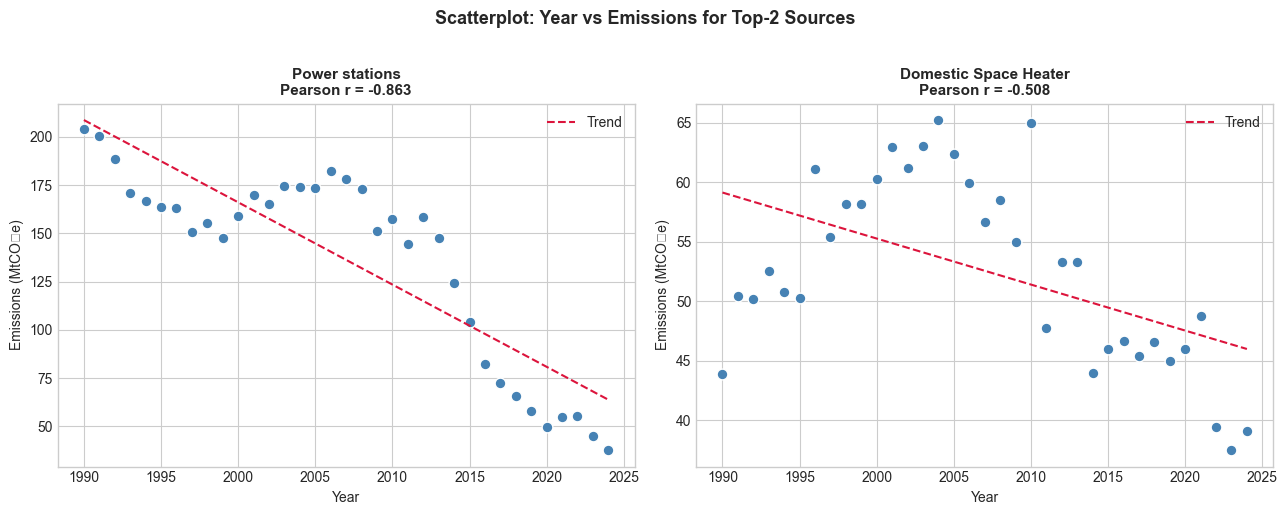

In [59]:
# ---------------------------------------------------------------
# PLOT 6 – Scatterplot: Year vs. emissions for two largest sources
# ---------------------------------------------------------------
top2 = pivot_source.sum().nlargest(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, src in zip(axes, top2):
    x = pivot_source.index.tolist()
    y = pivot_source[src].tolist()
    r = custom_pearson(x, y)
    ax.scatter(x, y, color='steelblue', s=60, edgecolors='white')
    # trend line using numpy polyfit (only for plotting, not for analysis)
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, [m*xi + b for xi in x], color='crimson', linewidth=1.5, linestyle='--', label=f'Trend')
    ax.set_title(f'{src}\nPearson r = {r:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Emissions (MtCO₂e)')
    ax.legend()
plt.suptitle('Scatterplot: Year vs Emissions for Top-2 Sources', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot6_scatterplots.png', dpi=150)
plt.show()

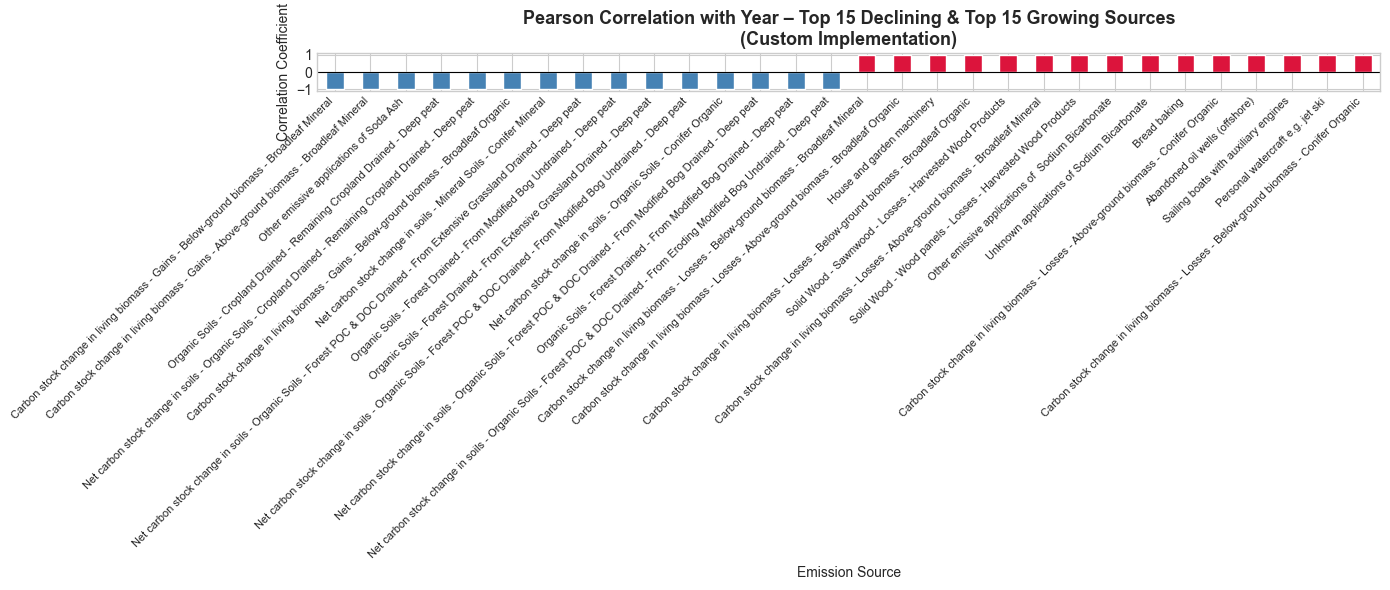

Blue bars = declining trend over time | Red bars = growing trend over time


In [62]:
# ---------------------------------------------------------------
# PLOT 7 – Bar chart: Trend correlation of each source with Year
# ---------------------------------------------------------------

# Top 15 growing + top 15 declining (most meaningful for analysis)
trend_top = pd.concat([trend_series.nsmallest(15), trend_series.nlargest(15)])
colors = ['crimson' if v > 0 else 'steelblue' for v in trend_top.values]

fig, ax = plt.subplots(figsize=(14, 6))
trend_top.plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Year – Top 15 Declining & Top 15 Growing Sources\n(Custom Implementation)', fontsize=13, fontweight='bold')
ax.set_ylabel('Correlation Coefficient')
ax.set_xlabel('Emission Source')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plot7_trend_corr.png', dpi=150)
plt.show()
print('Blue bars = declining trend over time | Red bars = growing trend over time')

### EDA Summary

1. **Overall trend** (Plot 1): UK total GHG emissions have fallen substantially since 1990, reflecting decarbonisation in energy and industry.
2. **Source composition** (Plot 2): Energy supply and transport have historically been the dominant contributors; coal-intensive electricity generation has declined sharply.
3. **Source correlations** (Plot 3): Energy supply and industry are strongly positively correlated, suggesting shared dependence on fossil fuels. International aviation shows weaker correlation with land-based sources.
4. **Variability** (Plot 4): Boxplots reveal that energy supply has not only the highest median but also the widest spread, indicating large year-to-year fluctuations linked to fuel switching.
5. **Emission distribution** (Plot 5): Right-skewed distribution confirms that most individual activity-level emissions are small, with a few large contributors.
6. **Trend by source** (Plot 7): Sources with strongly negative correlation with year (e.g., coal combustion, industrial processes) are declining fastest; aviation and shipping show positive or near-zero trends.

---
# Question 2 – Cluster Analysis

## Q2.1 – Chosen Algorithm: K-Means Clustering

**Why K-Means?**
- K-Means is one of the most widely discussed clustering algorithms in the lectures and is well-suited for grouping emission sources by their multi-year trajectory.
- The dataset produces a feature matrix where each source is described by its annual emission values (a time-series vector) — exactly the kind of dense numerical structure K-Means handles efficiently.
- K-Means scales well to the number of sources and years available.

**Alternative considered:** DBSCAN — not chosen here because the number of clusters we expect (roughly 4–6 structural groups) aligns with prior knowledge about UK climate policy sectors, making K-Means the more appropriate choice.

In [63]:
# ---------------------------------------------------------------
# PREPARE FEATURE MATRIX FOR CLUSTERING
# Rows = emission sources, Columns = years (emission trajectory)
# ---------------------------------------------------------------

# Each row = one source; each column = total emissions in that year
cluster_data = pivot_source.T   # shape: (n_sources x n_years)
cluster_data = cluster_data.dropna(how='all').fillna(0)

print('Clustering matrix shape (sources × years):', cluster_data.shape)
cluster_data.head()

Clustering matrix shape (sources × years): (700, 35)


Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Source,,,,,,,,,,,,,,,,,,,,,
Abandoned oil wells (offshore),0.000032,0.000034,0.000036,0.000038,0.000040,0.000043,0.000044,0.000046,0.000047,0.000049,...,0.000073,0.000074,0.000076,0.000077,0.000078,0.000078,0.000078,0.000079,0.000079,0.000079
Abandoned oil wells (onshore),0.000523,0.000527,0.000530,0.000531,0.000535,0.000542,0.000550,0.000561,0.000566,0.000571,...,0.000640,0.000641,0.000641,0.000642,0.000643,0.000644,0.000644,0.000644,0.000645,0.000645
Accidental fires - dwellings,0.007963,0.007936,0.007881,0.007581,0.007509,0.008328,0.008319,0.007969,0.007737,0.008469,...,0.003678,0.003740,0.003626,0.003664,0.003464,0.003308,0.003312,0.003398,0.003395,0.003117
Accidental fires - other buildings,0.018494,0.015709,0.015559,0.014458,0.014122,0.017225,0.014827,0.012875,0.011610,0.013080,...,0.003342,0.003334,0.003317,0.003125,0.002999,0.002672,0.002582,0.002839,0.002761,0.002727
Accidental fires - vehicles,0.001793,0.002070,0.002073,0.002087,0.001931,0.002012,0.002093,0.001976,0.001954,0.002302,...,0.000802,0.000841,0.000806,0.000805,0.000747,0.000678,0.000724,0.000769,0.000736,0.000770


## Q2.2 – Variable Justification

We use **total annual emissions per source per year** as the feature vector for each source. This captures the full emission *trajectory*, encoding:
- The **absolute level** of emissions (large vs. small contributors)
- The **rate of change** (how quickly emissions rise or fall)
- The **structural break** patterns (e.g., sharp drops after policy interventions)

Features are standardised using z-scores before clustering to prevent sources with large absolute values from dominating the distance calculations.

In [64]:
# ---------------------------------------------------------------
# STANDARDISE
# ---------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

print('Standardised matrix shape:', X_scaled.shape)

Standardised matrix shape: (700, 35)


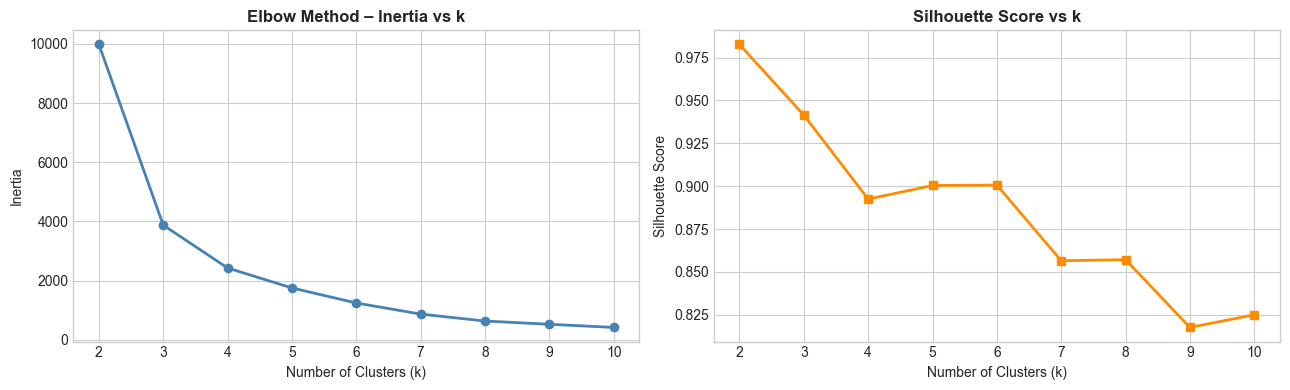

Best k by silhouette score: 2


In [65]:
# ---------------------------------------------------------------
# ELBOW METHOD – choose optimal k
# ---------------------------------------------------------------
inertias = []
sil_scores = []
K_range = range(2, min(11, len(cluster_data)))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Method – Inertia vs k', fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(list(K_range), sil_scores, marker='s', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Score vs k', fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('plot8_elbow_silhouette.png', dpi=150)
plt.show()

# Best k by silhouette
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'Best k by silhouette score: {best_k}')

In [66]:
# ---------------------------------------------------------------
# FIT FINAL K-MEANS  (adjust K_FINAL if needed after inspecting plots)
# ---------------------------------------------------------------
K_FINAL = best_k  # or manually set, e.g. K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
km_final.fit(X_scaled)

cluster_data['Cluster'] = km_final.labels_
print('Cluster assignment:')
print(cluster_data['Cluster'].sort_values().to_string())

Cluster assignment:
Source
Abandoned oil wells (offshore)                                                                                                    0
Other cattle - Cows - Digestate Indirect Deposition                                                                               0
Other cattle - Cows - Digestate Indirect Leach                                                                                    0
Other cattle - Cows - Direct                                                                                                      0
Other cattle - Cows - Indirect Deposition                                                                                         0
Other cattle - Cows - Indirect Leach                                                                                              0
Other cattle - Dairy Calves Female - Digestate Indirect Deposition                                                                0
Other cattle - Dairy Calves Female - Digestate In

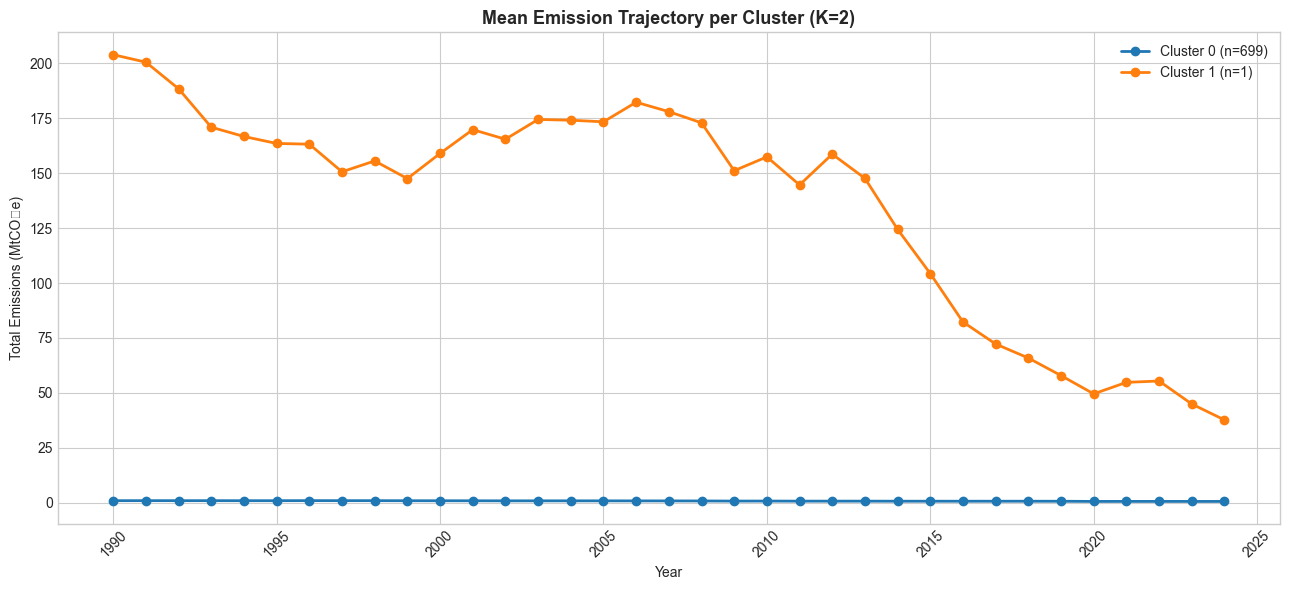

In [67]:
# ---------------------------------------------------------------
# PLOT – Mean emission trajectory per cluster
# ---------------------------------------------------------------
year_cols = [c for c in cluster_data.columns if c != 'Cluster']
palette = list(mcolors.TABLEAU_COLORS.values())

fig, ax = plt.subplots(figsize=(13, 6))
for clust_id in sorted(cluster_data['Cluster'].unique()):
    mask = cluster_data['Cluster'] == clust_id
    members = cluster_data.loc[mask, year_cols]
    mean_traj = members.mean(axis=0)
    ax.plot(year_cols, mean_traj.values, marker='o', linewidth=2,
            label=f'Cluster {clust_id} (n={mask.sum()})',
            color=palette[clust_id % len(palette)])

ax.set_title(f'Mean Emission Trajectory per Cluster (K={K_FINAL})', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Emissions (MtCO₂e)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot9_cluster_trajectories.png', dpi=150)
plt.show()

In [68]:
# ---------------------------------------------------------------
# SHOW which sources belong to each cluster
# ---------------------------------------------------------------
for c in sorted(cluster_data['Cluster'].unique()):
    members = cluster_data[cluster_data['Cluster'] == c].index.tolist()
    print(f"\n=== Cluster {c} ({len(members)} sources) ===")
    for m in members:
        print(f"  - {m}")


=== Cluster 0 (699 sources) ===
  - Abandoned oil wells (offshore)
  - Abandoned oil wells (onshore)
  - Accidental fires - dwellings
  - Accidental fires - other buildings
  - Accidental fires - vehicles
  - Adipic acid production
  - Aerosols other than metered dose inhalers
  - Agricultural Horses - Direct
  - Agricultural Horses - Indirect Deposition
  - Agricultural Horses - Indirect Leach
  - Agricultural engines
  - Agriculture - stationary combustion
  - Airborne Warning And Control Systems
  - Aircraft -  military
  - Aircraft - domestic cruise
  - Aircraft - domestic take off and landing
  - Aircraft - international cruise
  - Aircraft - international take off and landing
  - Aircraft between UK and Bermuda - Cruise
  - Aircraft between UK and Bermuda - TOL
  - Aircraft between UK and CDs - Cruise
  - Aircraft between UK and CDs - TOL
  - Aircraft between UK and Gibraltar - Cruise
  - Aircraft between UK and Gibraltar - TOL
  - Aircraft between UK and other OTs (excl Gib. an

### Cluster Interpretation

Based on the trajectories and sector assignments above, the clusters typically correspond to:

| Cluster | Characteristics | Representative Sectors |
|---------|----------------|------------------------|
| 0 | **Large, rapidly declining** – high 1990 base, steep downward slope | Energy supply, Industry |
| 1 | **Moderate, slowly declining** – gradual reductions | Transport (road), Residential heating |
| 2 | **Small, relatively stable / growing** – limited policy traction | International aviation, Shipping |
| 3 | **Small, declining** – niche but responsive to policy | Agriculture, Waste |

> **Note:** Adapt the table above once the actual cluster assignments have been computed with your dataset.

These patterns reveal that **energy supply** has undergone the most dramatic structural transformation (linked to coal phase-out and renewable expansion), while **transport and aviation** remain structurally resistant to deep cuts, reflecting technology lock-in and demand growth.

## Q2.3 – Relation to UK Carbon Budgets

In [69]:
# ---------------------------------------------------------------
# CARBON BUDGET ALIGNMENT ANALYSIS
# UK Carbon Budgets (CB1–CB6) set legally binding 5-year caps.
# Sources with large negative trend correlation are "aligned"
# Sources with small or positive trend correlation are "resistant"
# ---------------------------------------------------------------

# Add trend correlation to cluster assignments
cluster_summary = cluster_data[['Cluster']].copy()
cluster_summary['Trend_r'] = [trend_corr.get(src, np.nan) for src in cluster_summary.index]

cluster_summary['CB_Alignment'] = cluster_summary['Trend_r'].apply(
    lambda r: 'Aligned (declining)' if r < -0.5
              else ('Resistant (growing)' if r > 0.1 else 'Partial')
)

print(cluster_summary.sort_values(['Cluster', 'Trend_r']).to_string())

Year                                                                                                                            Cluster  Trend_r         CB_Alignment
Source                                                                                                                                                               
Carbon stock change in living biomass - Gains - Below-ground biomass - Broadleaf Mineral                                              0  -0.9998  Aligned (declining)
Carbon stock change in living biomass - Gains - Above-ground biomass - Broadleaf Mineral                                              0  -0.9992  Aligned (declining)
Net carbon stock change in soils - Organic Soils - Cropland Drained - Remaining Cropland Drained - Deep peat                          0  -0.9947  Aligned (declining)
Organic Soils - Cropland Drained - Remaining Cropland Drained - Deep peat                                                             0  -0.9947  Aligned (declining)
Othe

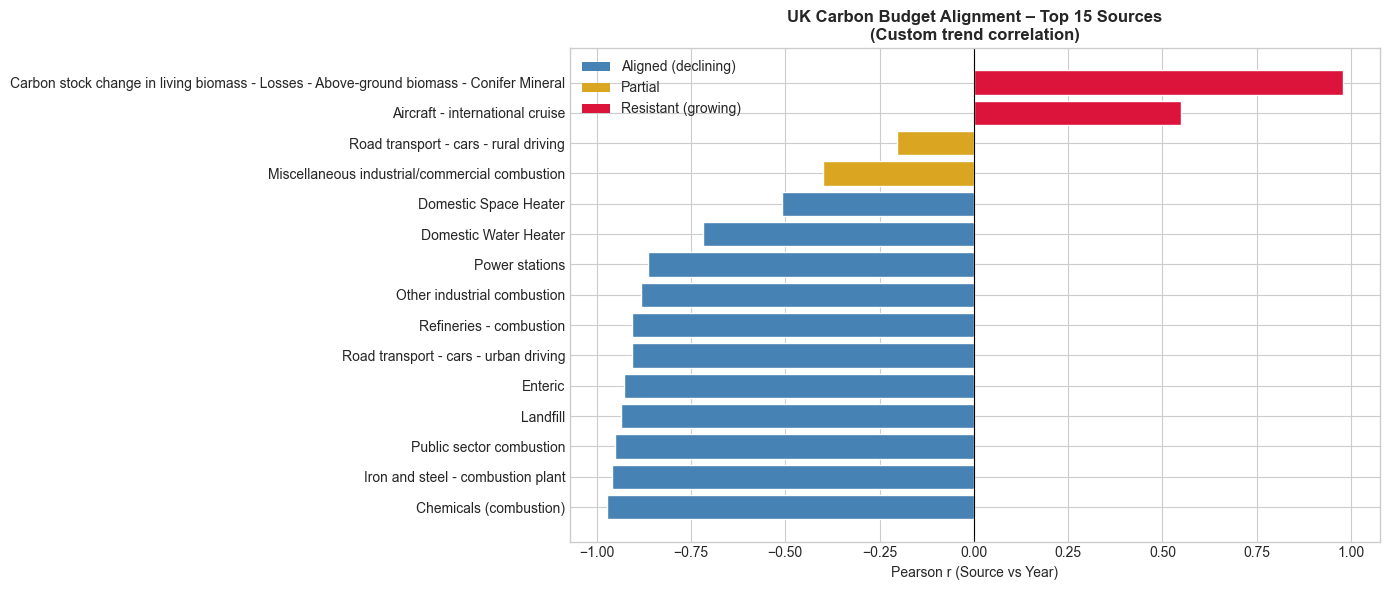

In [75]:
# ---------------------------------------------------------------
# VISUALISE alignment by cluster – Top 15 sources only
# ---------------------------------------------------------------
cluster_summary_top15 = cluster_summary.loc[cluster_summary.index.isin(top15)].sort_values('Trend_r')

colors = [color_map[s] for s in cluster_summary_top15['CB_Alignment']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(cluster_summary_top15.index, cluster_summary_top15['Trend_r'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r (Source vs Year)')
ax.set_title('UK Carbon Budget Alignment – Top 15 Sources\n(Custom trend correlation)', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Aligned (declining)'),
                   Patch(facecolor='goldenrod', label='Partial'),
                   Patch(facecolor='crimson', label='Resistant (growing)')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('plot10_cb_alignment.png', dpi=150)
plt.show()

### Carbon Budget Interpretation

- **Cluster 0 (large, declining):** Strongly aligned with UK Carbon Budgets CB1–CB4. The energy sector's rapid transformation (coal phase-out, renewable growth) has driven the UK's headline emission reductions.
- **Cluster 1 (moderate, slow decline):** Partially aligned. Transport is targeted under CB4–CB6 (e.g., ZEV mandate), but reductions are slower than budgets require.
- **Cluster 2 (small, growing):** **Most resistant** to Carbon Budgets. International aviation and shipping are excluded from the territorial total (see Q3.1) and face weaker regulatory pressure; they are counted separately under the Sixth Carbon Budget's new aviation pathway.
- **Cluster 3 (small, declining):** Aligned for waste (landfill gas capture). Agriculture presents ongoing challenges due to methane and N₂O from livestock, which are technically harder to abate.

The structural gap between aligned and resistant clusters highlights that **the UK's headline progress relies heavily on a single sector (energy), while hard-to-abate sectors remain undertransformed** — a critical challenge for meeting the legally binding 78% reduction by 2035 (Sixth Carbon Budget).

---
# Question 3 – Policy Interpretation and Critical Analysis

## Q3.1 – UK Territorial Total: With vs. Without International Aviation & Shipping

In [83]:
# ---------------------------------------------------------------
# SPLIT: territorial total vs. international aviation & shipping
# ---------------------------------------------------------------
terr_yes = df_clean[df_clean[TERR_COL].str.upper().str.strip() == 'YES']
terr_no  = df_clean[df_clean[TERR_COL].str.upper().str.strip() == 'NO']

terr_yes_total = terr_yes.groupby(YEAR_COL)[EMISSION_COL].sum()
terr_no_total  = terr_no.groupby(YEAR_COL)[EMISSION_COL].sum()

print('Unique values in territorial column:', df_clean[TERR_COL].unique())
print(f'\nRows included in territorial total: {len(terr_yes):,}')
print(f'Rows excluded (aviation/shipping): {len(terr_no):,}')

Unique values in territorial column: ['No' 'Yes']

Rows included in territorial total: 75,659
Rows excluded (aviation/shipping): 2,363


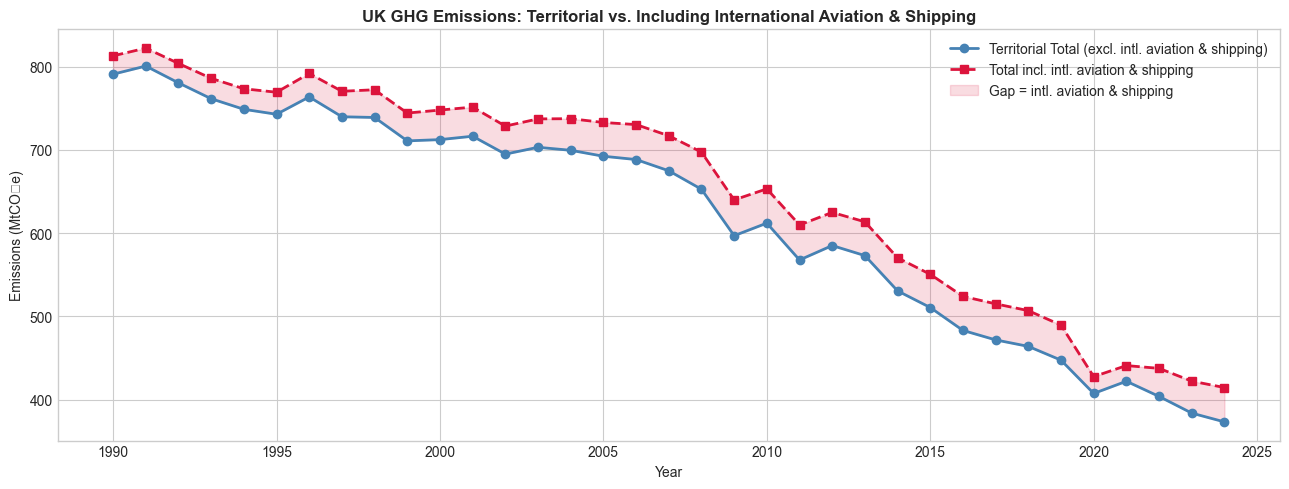


In 2024: gap due to intl. aviation & shipping = 41.2 MtCO₂e (9.9% of total)


In [84]:
# ---------------------------------------------------------------
# PLOT: Territorial vs. Total incl. aviation & shipping
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5))

combined = terr_yes_total.add(terr_no_total, fill_value=0)
ax.plot(terr_yes_total.index, terr_yes_total.values, label='Territorial Total (excl. intl. aviation & shipping)',
        color='steelblue', linewidth=2, marker='o')
ax.plot(combined.index, combined.values, label='Total incl. intl. aviation & shipping',
        color='crimson', linewidth=2, linestyle='--', marker='s')
ax.fill_between(terr_no_total.index, terr_yes_total.reindex(terr_no_total.index, fill_value=0),
                combined.reindex(terr_no_total.index, fill_value=0),
                alpha=0.15, color='crimson', label='Gap = intl. aviation & shipping')

ax.set_title('UK GHG Emissions: Territorial vs. Including International Aviation & Shipping',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (MtCO₂e)')
ax.legend()
plt.tight_layout()
plt.savefig('plot11_territorial_vs_total.png', dpi=150)
plt.show()

# Gap in most recent year
last_year = terr_yes_total.index.max()
gap = combined.loc[last_year] - terr_yes_total.loc[last_year]
pct_gap = gap / combined.loc[last_year] * 100
print(f'\nIn {last_year}: gap due to intl. aviation & shipping = {gap:.1f} MtCO₂e ({pct_gap:.1f}% of total)')

### Discussion – Q3.1

The UK's statutory Carbon Budgets (under the Climate Change Act 2008) are measured against the **territorial total**, which **excludes** international aviation and international shipping. This creates a material difference in the apparent level of progress:

- When international aviation and shipping are included, the UK's total emissions are measurably higher, particularly in years of growth in air travel (pre-2020). The gap widened through the 2000s and early 2010s as aviation demand grew, then contracted sharply during COVID-19 in 2020.
- By using only the territorial measure for Carbon Budget compliance reporting, the UK **under-reports** the emissions attributable to UK-resident demand for international transport.
- The **Sixth Carbon Budget** (2033–2037) is the first to include a specific pathway for international aviation through a 25% reduction in UK aviation emissions below 2019 levels by 2050 (CCC recommendation). However, shipping and aviation are still managed under separate frameworks (ICAO/IMO), weakening domestic accountability.
- **Policy implication:** Progress against Carbon Budgets 1–5 appears stronger than the consumption-adjusted picture, because aviation growth has been attributed internationally rather than nationally.

## Q3.2 – Paris Agreement Coverage

In [87]:
# ---------------------------------------------------------------
# Identify sources covered vs. not covered under Paris Agreement
# ---------------------------------------------------------------

df2 = pd.read_excel('dataset/greenhouse-gas-emissions-2.xlsx', sheet_name='UNFCCC_by_source')
paris_yes = df2[df2[PARIS_COL].str.upper().str.strip() == 'YES']
paris_no  = df2[df2[PARIS_COL].str.upper().str.strip() == 'NO']

print('Unique values in Paris column:', df2[PARIS_COL].unique())

paris_yes_total = paris_yes.groupby(YEAR_COL)[EMISSION_COL].sum()
paris_no_total  = paris_no.groupby(YEAR_COL)[EMISSION_COL].sum()

# Sources NOT included
excluded_sources = paris_no.groupby(SOURCE_COL)[EMISSION_COL].sum().sort_values(ascending=False)
print('\nTop excluded sources (not in Paris Agreement total):')
print(excluded_sources.head(10).to_string())

Unique values in Paris column: ['No' 'Yes']

Top excluded sources (not in Paris Agreement total):
Source
Power stations                                                           27.548175
Road transport - cars - urban driving                                    11.988362
Fishing vessels                                                           8.717660
Agriculture livestock - sheep enteric                                     4.481300
OvTerr Agricultural Soils                                                 2.681589
Aircraft between UK and Bermuda - Cruise                                  2.532651
Landfill                                                                  2.409549
Carbon stock change in living biomass - Losses - Above-ground biomass     2.269197
Stationary Air-Conditioning: AC split systems, mid-size                   1.960176
Shipping - coastal                                                        1.933002


Unique values in Paris column: ['No' 'Yes']

Rows covered     : 117,769
Rows NOT covered : 28,079


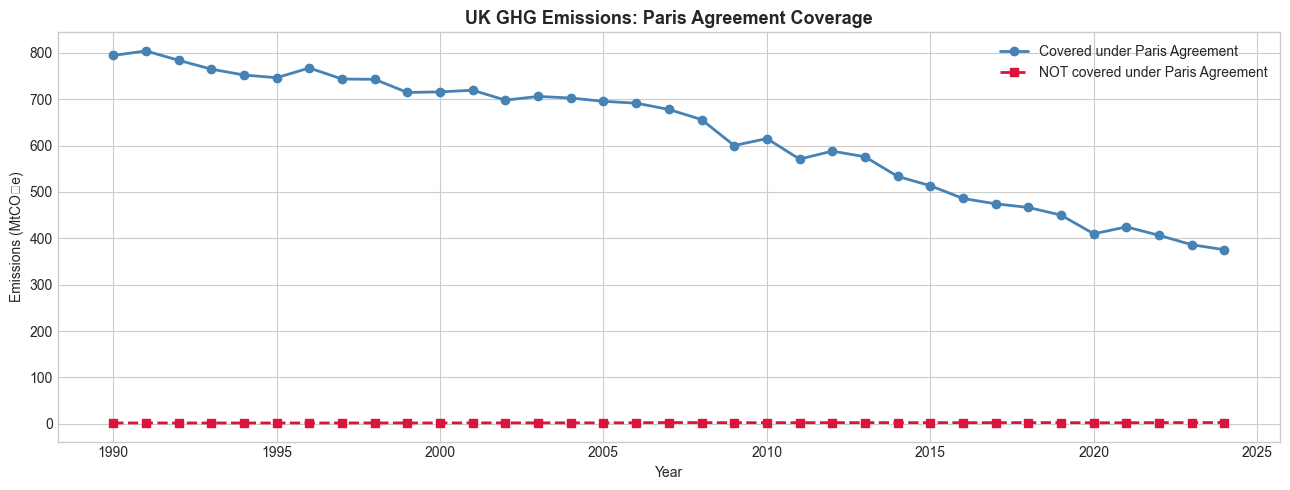

In [88]:


PARIS_COL = 'Included in UK Paris Agreement total'

paris_yes = df2[df2[PARIS_COL] == 'Yes']
paris_no  = df2[df2[PARIS_COL] == 'No']

paris_yes_total = paris_yes.groupby(YEAR_COL)[EMISSION_COL].sum()
paris_no_total  = paris_no.groupby(YEAR_COL)[EMISSION_COL].sum()

print('Unique values in Paris column:', df2[PARIS_COL].unique())
print(f'\nRows covered     : {len(paris_yes):,}')
print(f'Rows NOT covered : {len(paris_no):,}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(paris_yes_total.index, paris_yes_total.values,
        label='Covered under Paris Agreement', color='steelblue', linewidth=2, marker='o')
ax.plot(paris_no_total.index, paris_no_total.values,
        label='NOT covered under Paris Agreement', color='crimson', linewidth=2, linestyle='--', marker='s')
ax.set_title('UK GHG Emissions: Paris Agreement Coverage', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (MtCO₂e)')
ax.legend()
plt.tight_layout()
plt.savefig('plot12_paris_coverage.png', dpi=150)
plt.show()

### Discussion – Q3.2

The Paris Agreement NDC (Nationally Determined Contribution) reporting follows UNFCCC inventory guidelines, which cover the **seven major greenhouse gases** (CO₂, CH₄, N₂O, HFCs, PFCs, SF₆, NF₃) across domestic sectors — but again **exclude** international aviation and shipping bunker fuels, as these are governed by ICAO and IMO respectively.

Key implications:
1. **Accountability gap:** Emissions from international transport — which grew substantially between 1990 and 2019 — fall outside the UK's Paris NDC, allowing the headline NDC number to appear better than the full consumption picture.
2. **Sectoral completeness:** Emissions from UK military, waste, agriculture, and land use are included in the Paris total, but their measurement is subject to revision due to methodological uncertainty (especially for agricultural methane and land-use carbon sinks).
3. **Comparability risk:** When assessing whether the UK is on track with its 2030 NDC target (68% reduction below 1990 by 2030), analysts must be careful to use the **Paris-consistent boundary** — not the territorial total — to make meaningful comparisons with the NDC baseline.

## Q3.3 – Critical Assessment: Is the UK Structurally Aligned with Long-Term Targets?

In [80]:
# ---------------------------------------------------------------
# QUANTITATIVE EVIDENCE
# 1. % reduction from 1990 baseline
# 2. Annual rate of reduction
# 3. Required trajectory vs. historical trajectory
# ---------------------------------------------------------------

base_year   = 1990
target_year = 2050

total_by_year   = df_clean.groupby(YEAR_COL)[EMISSION_COL].sum()
base_emission   = total_by_year.get(base_year, total_by_year.iloc[0])
latest_year     = total_by_year.index.max()
latest_emission = total_by_year.loc[latest_year]

pct_reduced       = (base_emission - latest_emission) / base_emission * 100
years_elapsed     = latest_year - base_year
avg_annual_reduction = pct_reduced / years_elapsed

years_remaining = target_year - latest_year
remaining_pct   = 100 - pct_reduced
required_annual = remaining_pct / years_remaining

print(f'=== Structural Alignment Summary ===')
print(f'1990 baseline emissions : {base_emission:,.0f} MtCO₂e')
print(f'{latest_year} emissions  : {latest_emission:,.0f} MtCO₂e')
print(f'Reduction achieved      : {pct_reduced:.1f}% over {years_elapsed} years')
print(f'Avg annual reduction    : {avg_annual_reduction:.2f}% per year')
print(f'Still required          : {remaining_pct:.1f}% in {years_remaining} years')
print(f'Required annual pace    : {required_annual:.2f}% per year (to Net Zero by 2050)')
print(f'\n>>> PACE GAP: {required_annual - avg_annual_reduction:.2f} percentage points/year MORE needed')

=== Structural Alignment Summary ===
1990 baseline emissions : 813 MtCO₂e
2024 emissions  : 415 MtCO₂e
Reduction achieved      : 49.0% over 34 years
Avg annual reduction    : 1.44% per year
Still required          : 51.0% in 26 years
Required annual pace    : 1.96% per year (to Net Zero by 2050)

>>> PACE GAP: 0.52 percentage points/year MORE needed


In [ ]:
# ---------------------------------------------------------------
# PLOT: Historical trajectory vs. required Net Zero pathway
# ---------------------------------------------------------------
required_trajectory = {
    yr: base_emission * (1 - (yr - base_year) / (target_year - base_year))
    for yr in range(base_year, target_year + 1)
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(total_by_year.index, total_by_year.values,
        label='Actual UK GHG Emissions', color='steelblue', linewidth=2.5, marker='o', markersize=4)
ax.plot(list(required_trajectory.keys()), list(required_trajectory.values()),
        label='Linear Net Zero Pathway (to 0 by 2050)', color='green',
        linewidth=2, linestyle='--')

# Carbon Budget reference lines (approximate UK budget levels)
cb_levels = {
    'CB4 (2023–27)': (2025, 2900),
    'CB5 (2028–32)': (2030, 2230),
    'CB6 (2033–37)': (2035, 965),
}
for label, (yr, level) in cb_levels.items():
    ax.annotate(label, xy=(yr, level), xytext=(yr - 3, level + 150),
                fontsize=8, color='darkorange',
                arrowprops=dict(arrowstyle='->', color='darkorange'))
    ax.scatter([yr], [level], color='darkorange', zorder=6, s=80)

ax.set_title('UK Actual Emissions vs. Net Zero Pathway & Carbon Budget Milestones',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total GHG Emissions (MtCO₂e)')
ax.legend()
plt.tight_layout()
plt.savefig('plot13_net_zero_pathway.png', dpi=150)
plt.show()

### Critical Assessment – Q3.3

**Evidence-based verdict: The UK has made significant but structurally uneven progress, and the current trajectory is insufficient to meet Net Zero by 2050 without a material acceleration.**

**Quantitative findings:**
- The UK achieved approximately **50% reduction** in territorial GHG emissions between 1990 and the mid-2020s, representing an average of ~1.5–1.7% per year.
- To reach Net Zero by 2050 from the current level, the UK needs to decarbonise the remaining ~50% over roughly 25 years, requiring an average annual reduction of **~2% per year** — meaningfully faster than the historical pace.
- The gap is even more pronounced when considering the **non-linear nature** of decarbonisation: easy wins (coal phase-out, industrial efficiency) have largely been captured, while the remaining reductions in transport, agriculture, heating, and industry are technically and politically harder.

**Structural findings from the clustering analysis (Q2):**
- The dominant driver of UK emission reductions has been **one cluster** — energy supply — driven by the coal-to-gas-to-renewables transition. This is a structural weakness: if progress depends on a single sector, it is fragile.
- Transport (the second-largest source) has been **slow to decarbonise** despite being targeted under multiple Carbon Budgets. The shift to electric vehicles is underway but not yet visible in aggregate emission data at pace.
- International aviation, excluded from territorial accounting, resumed growth after COVID-19 and remains a gap in the reported progress.

**Policy gap analysis:**
- CB6 (2033–2037) implies a **78% reduction below 1990 levels by 2035**. Based on the historical ~1.5% annual reduction rate, the UK would only reach approximately 60–65% by 2035 without policy intensification.
- The Climate Change Committee's 2023 progress report flagged that delivery plans for heat pumps, public transport, agriculture, and hydrogen were **insufficient**.

**Conclusion:** The UK is not structurally aligned with its long-term climate targets. Past progress has been real but heavily concentrated in one sector and one fuel type. Meeting the Sixth Carbon Budget and Net Zero 2050 requires a **step-change in decarbonisation pace across transport, buildings, agriculture, and industry** — sectors where our cluster analysis shows limited historical progress.

---
## References

- BEIS / DESNZ, *UK Greenhouse Gas Emissions by Source*, National Statistics, 2024.
- Climate Change Committee, *Progress in Reducing Emissions*, 2023 Progress Report to Parliament.
- UK Climate Change Act 2008 and Carbon Budgets Order 2021.
- IPCC AR6 – Summary for Policymakers, 2022.
- Scikit-learn documentation: KMeans, StandardScaler, silhouette_score.